## Practice Lecture 18 - Training DNN
In this lab we will look at how to train Deep Neural Networks for classification and regression. \
Based on Chapter 11 from Aurelien Geron's book, Hands-on Machine Learning with Scikit-Learn Keras & Tensorflow.\
Original code examples from book in github [here](https://github.com/ageron/handson-ml2)

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/dtrad/geoml_course/blob/master/Practice18_trainingDNN.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
except Exception:
    pass

# TensorFlow ≥2.0 is required
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt


## Exercise 1: activation functions
Plot activation functions logit, relu and leaky-relu

In [6]:
z=np.arange(-5,5,0.1)

In [7]:
def logit(z):
    return 1 / (1 + np.exp(-z))

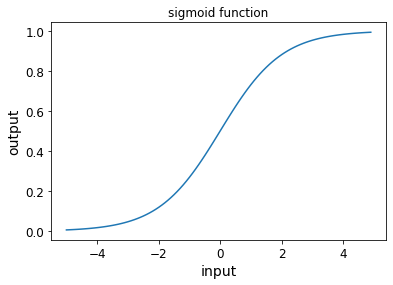

In [10]:
plt.figure()
plt.plot(z,logit(z))
plt.xlabel('input')
plt.ylabel('output')
plt.title('sigmoid function');

In [12]:
def leaky_relu(z, alpha=0.01):
    return np.maximum(alpha*z, z)

when Leaky Relu has coefficient $alpha=0$ it is the same as RELU

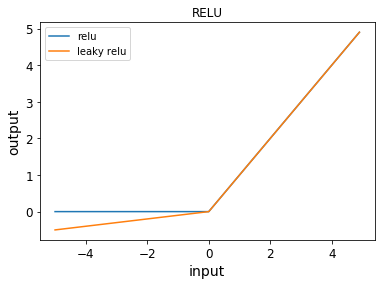

In [16]:
plt.plot(z,leaky_relu(z,0.0),label='relu')
plt.plot(z,leaky_relu(z,0.1),label='leaky relu')
plt.legend()
plt.xlabel('input')
plt.ylabel('output')
plt.title('RELU');

## Exercise 2: training for MNIST with different activation functions and initialization
Train a network for MNIST data using leaky_relu and compare with relu and sigmoid. Also compare two different initializations "he_init" and "zeros".\
For each case plot the loss and validations curves and evaluate on the test data.\
What does it work and what doesn't?

In [18]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

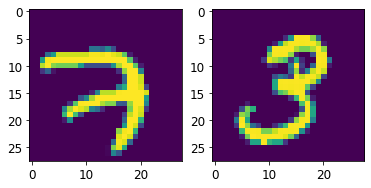

In [20]:
plt.figure()
plt.subplot(121);plt.imshow(X_train[0])
plt.subplot(122);plt.imshow(X_train[1]);


In [ ]:
[m for m in dir(keras.initializers) if not m.startswith("_")]

In [ ]:
[m for m in dir(keras.activations) if not m.startswith("_")]

In [ ]:
[m for m in dir(keras.layers) if "relu" in m.lower()]

In [21]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(),
    keras.layers.Dense(100, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(),
    keras.layers.Dense(10, activation="softmax")
])

In [22]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(lr=1e-3),
              metrics=["accuracy"])

In [23]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 300)               235500    
_________________________________________________________________
leaky_re_lu (LeakyReLU)      (None, 300)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 100)               30100     
_________________________________________________________________
leaky_re_lu_1 (LeakyReLU)    (None, 100)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 10)                1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
__________________________________________________

In [24]:
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 70us/sample - loss: 1.5155 - accuracy: 0.6216 - val_loss: 0.9224 - val_accuracy: 0.8082
Epoch 2/10
55000/55000 [==============================] - 3s 58us/sample - loss: 0.7324 - accuracy: 0.8307 - val_loss: 0.5774 - val_accuracy: 0.8610
Epoch 3/10
55000/55000 [==============================] - 3s 58us/sample - loss: 0.5351 - accuracy: 0.8618 - val_loss: 0.4629 - val_accuracy: 0.8792
Epoch 4/10
55000/55000 [==============================] - 3s 58us/sample - loss: 0.4560 - accuracy: 0.8777 - val_loss: 0.4066 - val_accuracy: 0.8914
Epoch 5/10
55000/55000 [==============================] - 3s 59us/sample - loss: 0.4124 - accuracy: 0.8862 - val_loss: 0.3730 - val_accuracy: 0.8984
Epoch 6/10
55000/55000 [==============================] - 3s 59us/sample - loss: 0.3840 - accuracy: 0.8924 - val_loss: 0.3491 - val_accuracy: 0.9052
Epoch 7/10
55000/55000 [==============================] -

In [25]:
model.evaluate(X_test,y_test)

10000/10000 [==============================] - 0s 48us/sample - loss: 0.3060 - accuracy: 0.9154


[0.3059845324397087, 0.9154]

In [26]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

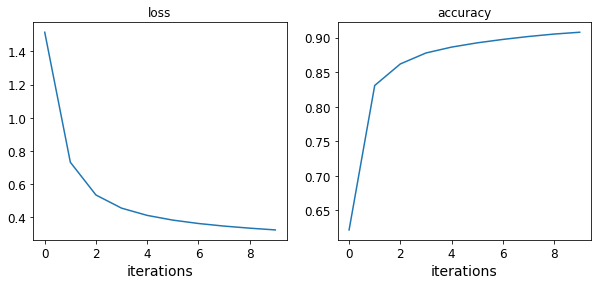

In [30]:
def plot_history(history):
    plt.figure(figsize=(10,4))
    plt.subplot(121);plt.plot(history.history["loss"])
    plt.xlabel('iterations')
    plt.title('loss')
    plt.subplot(122);plt.plot(history.history["accuracy"])
    plt.xlabel('iterations')
    plt.title('accuracy');
    
plot_history(history)

Let us compare with the standard RELU activation

In [32]:
model2 = keras.models.Sequential()
model2.add(keras.layers.Flatten(input_shape=[28,28]))
model2.add(keras.layers.Dense(300,activation="relu"))
model2.add(keras.layers.Dense(100,activation="relu"))
model2.add(keras.layers.Dense(10,activation="softmax"))

In [33]:
model2.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(lr=1e-3),
              metrics=["accuracy"])

In [34]:
model2.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_2 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_6 (Dense)              (None, 300)               235500    
_________________________________________________________________
dense_7 (Dense)              (None, 100)               30100     
_________________________________________________________________
dense_8 (Dense)              (None, 10)                1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [35]:
history2 = model2.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 65us/sample - loss: 1.8032 - accuracy: 0.5279 - val_loss: 1.2505 - val_accuracy: 0.7598
Epoch 2/10
55000/55000 [==============================] - 3s 57us/sample - loss: 0.9469 - accuracy: 0.8069 - val_loss: 0.7042 - val_accuracy: 0.8506
Epoch 3/10
55000/55000 [==============================] - 3s 59us/sample - loss: 0.6206 - accuracy: 0.8573 - val_loss: 0.5222 - val_accuracy: 0.8748
Epoch 4/10
55000/55000 [==============================] - 3s 57us/sample - loss: 0.4978 - accuracy: 0.8740 - val_loss: 0.4407 - val_accuracy: 0.8896
Epoch 5/10
55000/55000 [==============================] - 3s 56us/sample - loss: 0.4361 - accuracy: 0.8843 - val_loss: 0.3951 - val_accuracy: 0.8978
Epoch 6/10
55000/55000 [==============================] - 3s 59us/sample - loss: 0.3986 - accuracy: 0.8918 - val_loss: 0.3643 - val_accuracy: 0.9058
Epoch 7/10
55000/55000 [==============================] -

In [36]:
model2.evaluate(X_test,y_test)

10000/10000 [==============================] - 0s 46us/sample - loss: 0.3065 - accuracy: 0.9131


[0.3064620155274868, 0.9131]

In [55]:
print(history.params)
print(history2.params)

{'batch_size': 32, 'epochs': 10, 'steps': 1719, 'samples': 55000, 'verbose': 0, 'do_validation': True, 'metrics': ['loss', 'accuracy', 'val_loss', 'val_accuracy']}
{'batch_size': 32, 'epochs': 10, 'steps': 1719, 'samples': 55000, 'verbose': 0, 'do_validation': True, 'metrics': ['loss', 'accuracy', 'val_loss', 'val_accuracy']}


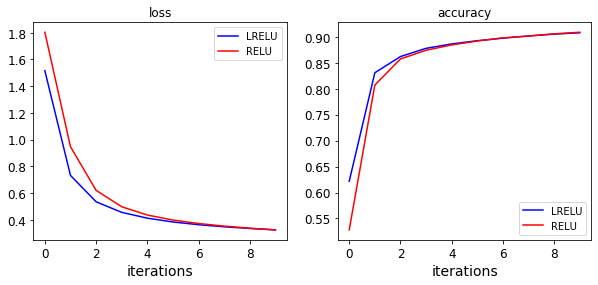

In [58]:
def plot_history(history, history2, case1, case2):
    niter=history.params['epochs']
    niter2=history.params['epochs']
    iter=np.arange(niter)
    iter2=np.arange(niter2)
    plt.figure(figsize=(10,4))
    plt.subplot(121);
    plt.plot(iter,history.history["loss"],'b-',label=case1);plt.plot(iter2,history2.history['loss'],'r-',label=case2)
    plt.xlabel('iterations')
    plt.title('loss')
    plt.legend()
    plt.subplot(122);
    plt.plot(iter,history.history["accuracy"],'b-',label=case1);plt.plot(iter2,history2.history['accuracy'],'r-',label=case2)
    plt.xlabel('iterations')
    plt.title('accuracy');
    plt.legend()
plot_history(history,history2,'LRELU','RELU')

We can see different activation functions implemented in Keras using dir(keras.activations)

In [61]:
[m for m in dir(keras.activations) if not m.startswith("_")]

['deserialize',
 'elu',
 'exponential',
 'get',
 'hard_sigmoid',
 'linear',
 'relu',
 'selu',
 'serialize',
 'sigmoid',
 'softmax',
 'softplus',
 'softsign',
 'tanh']

In [62]:
model3 = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, kernel_initializer="he_normal",activation="sigmoid"),
    keras.layers.Dense(100, kernel_initializer="he_normal",activation="sigmoid"),
    keras.layers.Dense(10, activation="softmax")
])
model3.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(lr=1e-3),
              metrics=["accuracy"])

In [63]:
history3 = model3.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))


Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 65us/sample - loss: 2.3180 - accuracy: 0.1381 - val_loss: 2.2756 - val_accuracy: 0.1234
Epoch 2/10
55000/55000 [==============================] - 3s 57us/sample - loss: 2.2621 - accuracy: 0.2115 - val_loss: 2.2466 - val_accuracy: 0.2634
Epoch 3/10
55000/55000 [==============================] - 3s 57us/sample - loss: 2.2325 - accuracy: 0.3382 - val_loss: 2.2161 - val_accuracy: 0.3550
Epoch 4/10
55000/55000 [==============================] - 4s 64us/sample - loss: 2.2006 - accuracy: 0.4310 - val_loss: 2.1826 - val_accuracy: 0.4362
Epoch 5/10
55000/55000 [==============================] - 3s 58us/sample - loss: 2.1655 - accuracy: 0.5041 - val_loss: 2.1451 - val_accuracy: 0.5300
Epoch 6/10
55000/55000 [==============================] - 3s 57us/sample - loss: 2.1259 - accuracy: 0.5529 - val_loss: 2.1023 - val_accuracy: 0.5798
Epoch 7/10
55000/55000 [==============================] -

In [64]:
model3.evaluate(X_test,y_test)

10000/10000 [==============================] - 0s 45us/sample - loss: 1.8591 - accuracy: 0.6485


[1.8590885452270507, 0.6485]

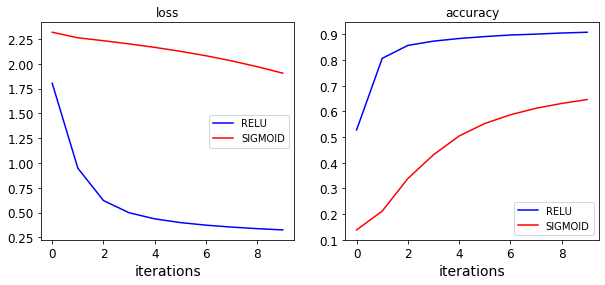

In [67]:
plot_history(history2,history3,'RELU','SIGMOID')

The same for initializers. We can check what is available by dir(keras.initializers)

In [68]:
[m for m in dir(keras.initializers) if not m.startswith("_")]

['Constant',
 'GlorotNormal',
 'GlorotUniform',
 'Identity',
 'Initializer',
 'Ones',
 'Orthogonal',
 'RandomNormal',
 'RandomUniform',
 'TruncatedNormal',
 'VarianceScaling',
 'Zeros',
 'constant',
 'deserialize',
 'get',
 'glorot_normal',
 'glorot_uniform',
 'he_normal',
 'he_uniform',
 'identity',
 'lecun_normal',
 'lecun_uniform',
 'ones',
 'orthogonal',
 'serialize',
 'zeros']

In [69]:
model4 = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, kernel_initializer="zeros",activation="sigmoid"),
    keras.layers.Dense(100, kernel_initializer="zeros",activation="sigmoid"),
    keras.layers.Dense(10, activation="softmax")
])
model4.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(lr=1e-3),
              metrics=["accuracy"])
history4 = model4.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))
model4.evaluate(X_test,y_test)

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 65us/sample - loss: 2.3198 - accuracy: 0.1065 - val_loss: 2.3007 - val_accuracy: 0.1126
Epoch 2/10
55000/55000 [==============================] - 3s 57us/sample - loss: 2.3014 - accuracy: 0.1123 - val_loss: 2.3003 - val_accuracy: 0.1126
Epoch 3/10
55000/55000 [==============================] - 3s 58us/sample - loss: 2.3014 - accuracy: 0.1123 - val_loss: 2.3011 - val_accuracy: 0.1126
Epoch 4/10
55000/55000 [==============================] - 3s 58us/sample - loss: 2.3013 - accuracy: 0.1122 - val_loss: 2.3007 - val_accuracy: 0.1126
Epoch 5/10
55000/55000 [==============================] - 3s 59us/sample - loss: 2.3013 - accuracy: 0.1123 - val_loss: 2.3006 - val_accuracy: 0.1126
Epoch 6/10
55000/55000 [==============================] - 3s 58us/sample - loss: 2.3012 - accuracy: 0.1125 - val_loss: 2.3002 - val_accuracy: 0.1126
Epoch 7/10
55000/55000 [==============================] -

[2.300752411651611, 0.1135]

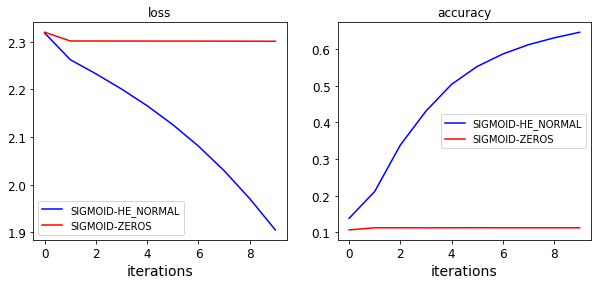

In [70]:
plot_history(history3,history4,'SIGMOID-HE_NORMAL','SIGMOID-ZEROS')

## Exercise 3: 
Use the first model with/without batch normalization. Plot the loss and accuracy curves for training and validation. Do you see any difference?
How many more parameters you need to optimize and why?

In [71]:
model5 = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(300, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(100, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(10, activation="softmax")
])

In [72]:
model5.summary()

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_5 (Flatten)          (None, 784)               0         
_________________________________________________________________
batch_normalization (BatchNo (None, 784)               3136      
_________________________________________________________________
dense_15 (Dense)             (None, 300)               235500    
_________________________________________________________________
leaky_re_lu_2 (LeakyReLU)    (None, 300)               0         
_________________________________________________________________
batch_normalization_1 (Batch (None, 300)               1200      
_________________________________________________________________
dense_16 (Dense)             (None, 100)               30100     
_________________________________________________________________
leaky_re_lu_3 (LeakyReLU)    (None, 100)              

In [73]:
model5.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(lr=1e-3),
              metrics=["accuracy"])
history5 = model5.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))
model5.evaluate(X_test,y_test)

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 6s 109us/sample - loss: 0.8808 - accuracy: 0.7275 - val_loss: 0.4907 - val_accuracy: 0.8594
Epoch 2/10
55000/55000 [==============================] - 5s 88us/sample - loss: 0.4768 - accuracy: 0.8609 - val_loss: 0.3847 - val_accuracy: 0.8910
Epoch 3/10
55000/55000 [==============================] - 5s 89us/sample - loss: 0.4071 - accuracy: 0.8807 - val_loss: 0.3371 - val_accuracy: 0.9034
Epoch 4/10
55000/55000 [==============================] - 5s 89us/sample - loss: 0.3693 - accuracy: 0.8926 - val_loss: 0.3090 - val_accuracy: 0.9102
Epoch 5/10
55000/55000 [==============================] - 5s 88us/sample - loss: 0.3425 - accuracy: 0.9007 - val_loss: 0.2909 - val_accuracy: 0.9146
Epoch 6/10
55000/55000 [==============================] - 5s 89us/sample - loss: 0.3225 - accuracy: 0.9051 - val_loss: 0.2766 - val_accuracy: 0.9206
Epoch 7/10
55000/55000 [==============================] 

[0.23611922463923693, 0.9325]

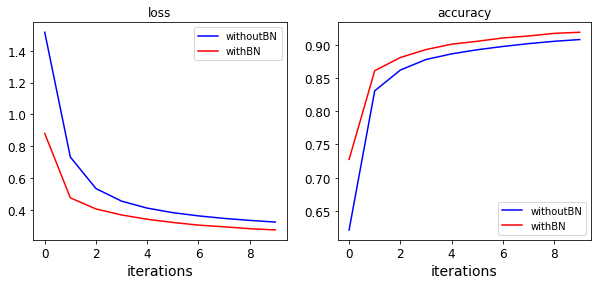

In [74]:
plot_history(history, history5, 'withoutBN','withBN')

## Exercise 4
Load the fashion_mnist model as shown below and train it to do multiclass classification as shown on the book's notebook.\
When training remove classes 8 and 9 to use them as a different dataset.\
Then take only these two classes and do binary classification on them.\
Instead of training the network from scratch, start from the network trained for the full data set. \
Replace the last layer for a sigmoid (softmax, i.e. multiclass, to sigmoid, binary classification). 

We take the full dataset first

In [79]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

Now we split the data into two new data sets, A and B. \
A has 7 classes (all original classes without 8 and 9) and can be classified with multiclass methods.\
B has 2 classes (Bag is false, Ankle Boot is True.\
We will train on the model A and then use it for B.\
That is we will switch from multiclass to binary classification.

In [115]:
print(class_names[8:10])
def split_dataset(X, y):
    y_8_or_9 = (y == 8) | (y == 9) # bag or ankle boots
    y_A = y[~y_8_or_9]    
    y_B = (y[y_8_or_9] == 9).astype(np.float32) # binary classification task, 8 False, 9 True
    return ((X[~y_8_or_9], y_A),
            (X[y_8_or_9], y_B))

(X_train_A, y_train_A), (X_train_B, y_train_B) = split_dataset(X_train, y_train)
(X_valid_A, y_valid_A), (X_valid_B, y_valid_B) = split_dataset(X_valid, y_valid)
(X_test_A, y_test_A), (X_test_B, y_test_B) = split_dataset(X_test, y_test)
X_train_B = X_train_B[:200]
y_train_B = y_train_B[:200]

['Bag', 'Ankle boot']


Let us check the indexes for model A and model B to make sure we did make mistakes.

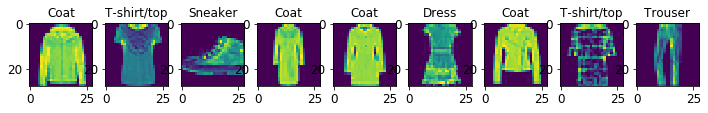

In [116]:
plt.figure(figsize=(12,6))
for i in range(9):    
    plt.subplot(191+i)
    plt.imshow(X_train_A[i]);plt.title(class_names[y_train_A[i]])

In [120]:
class_nameB=['bag','boot']

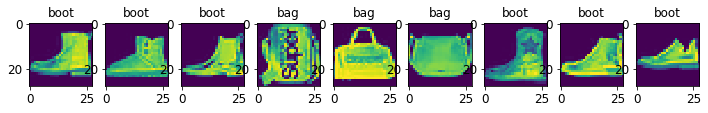

In [121]:
plt.figure(figsize=(12,6))
for i in range(9):    
    plt.subplot(191+i)
    plt.imshow(X_train_B[i]);plt.title(class_nameB[np.int8(y_train_B[i])])

Now we start training model A. We build a sequential model as we did before.

In [125]:
tf.random.set_seed(42)
np.random.seed(42)

In [126]:
model_A = keras.models.Sequential()
model_A.add(keras.layers.Flatten(input_shape=[28, 28]))
for n_hidden in (300, 100, 50, 50, 50):
    model_A.add(keras.layers.Dense(n_hidden, activation="selu"))
model_A.add(keras.layers.Dense(8, activation="softmax"))

But we train it using the dataset A. We will train from scratch.

In [127]:
model_A.compile(loss="sparse_categorical_crossentropy",
                optimizer=keras.optimizers.SGD(lr=1e-3),
                metrics=["accuracy"])
model_A.fit(X_train_A,y_train_A,validation_data=(X_valid_A,y_valid_A),epochs=10)

Train on 43996 samples, validate on 4004 samples
Epoch 1/10
43996/43996 [==============================] - 3s 76us/sample - loss: 0.7984 - accuracy: 0.7193 - val_loss: 0.5733 - val_accuracy: 0.7947
Epoch 2/10
43996/43996 [==============================] - 3s 63us/sample - loss: 0.5486 - accuracy: 0.8022 - val_loss: 0.5065 - val_accuracy: 0.8259
Epoch 3/10
43996/43996 [==============================] - 3s 63us/sample - loss: 0.5008 - accuracy: 0.8166 - val_loss: 0.4785 - val_accuracy: 0.8262
Epoch 4/10
43996/43996 [==============================] - 3s 65us/sample - loss: 0.4741 - accuracy: 0.8271 - val_loss: 0.4571 - val_accuracy: 0.8357
Epoch 5/10
43996/43996 [==============================] - 3s 63us/sample - loss: 0.4552 - accuracy: 0.8322 - val_loss: 0.4513 - val_accuracy: 0.8357
Epoch 6/10
43996/43996 [==============================] - 3s 62us/sample - loss: 0.4418 - accuracy: 0.8383 - val_loss: 0.4370 - val_accuracy: 0.8412
Epoch 7/10
43996/43996 [==============================] -

In [211]:
model_A.summary()

Model: "sequential_18"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_10 (Flatten)         (None, 784)               0         
_________________________________________________________________
dense_62 (Dense)             (None, 300)               235500    
_________________________________________________________________
dense_63 (Dense)             (None, 100)               30100     
_________________________________________________________________
dense_64 (Dense)             (None, 50)                5050      
_________________________________________________________________
dense_65 (Dense)             (None, 50)                2550      
_________________________________________________________________
dense_66 (Dense)             (None, 50)                2550      
_________________________________________________________________
dense_67 (Dense)             (None, 8)               

The main part of this exercise is to train for dataset B but starting from the model trained in dataset A.\
Notice that model A has never seeing a bag or ankle boot. Let use save the model first.

In [217]:
model_A.save("my_model_A.h5")

Now we will create a new model B by using layers from modelA except for the last one (the softmax with the softmax activation) since these layer was designed for multiclasses.\
We will replace this last layer with a simpler sigmoid (as usual for binary classification).

In [218]:
model_A = keras.models.load_model("my_model_A.h5")
model_B_on_A = keras.models.Sequential(model_A.layers[:-1])
model_B_on_A.add(keras.layers.Dense(1, activation="sigmoid"))

In [219]:
for i in np.arange(len(model_A.layers)): 
    print(model_A.layers[i].name,'\t',model_B_on_A.layers[i].name)

flatten_8 	 flatten_8
dense_30 	 dense_30
dense_31 	 dense_31
dense_32 	 dense_32
dense_33 	 dense_33
dense_34 	 dense_34
dense_35 	 dense_38


We need to fix the weights for all layers except the last one we want to change.

In [220]:
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = False

model_B_on_A.compile(loss="binary_crossentropy",
                     optimizer=keras.optimizers.SGD(lr=1e-3),
                     metrics=["accuracy"])

In [221]:
model_B_on_A.summary()

Model: "sequential_11"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_8 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_30 (Dense)             (None, 300)               235500    
_________________________________________________________________
dense_31 (Dense)             (None, 100)               30100     
_________________________________________________________________
dense_32 (Dense)             (None, 50)                5050      
_________________________________________________________________
dense_33 (Dense)             (None, 50)                2550      
_________________________________________________________________
dense_34 (Dense)             (None, 50)                2550      
_________________________________________________________________
dense_38 (Dense)             (None, 1)               

Now let us evaluate the models in the datasets A and B.\
Since model_A was already training for dataset A, it produces a good result for testA

In [222]:
model_A.evaluate(X_test_A, y_test_A)

8000/8000 [==============================] - 0s 55us/sample - loss: 0.4573 - accuracy: 0.8314


[0.4572983849644661, 0.831375]

The last layer of model_B_on_A has not been trained yet for dataset B. The rest of the layers are good. Let us try it to see if the last layer is important.

In [223]:
model_B_on_A.evaluate(X_test_B, y_test_B)

2000/2000 [==============================] - 0s 105us/sample - loss: 0.7875 - accuracy: 0.5765


[0.7874970107078553, 0.5765]

Let us now train the last layer.

In [224]:
history = model_B_on_A.fit(X_train_B, y_train_B, epochs=4,
                           validation_data=(X_valid_B, y_valid_B))
model_B_on_A.evaluate(X_test_B, y_test_B)

Train on 200 samples, validate on 996 samples
Epoch 1/4
200/200 [==============================] - 0s 2ms/sample - loss: 0.7685 - accuracy: 0.5400 - val_loss: 0.7678 - val_accuracy: 0.5863
Epoch 2/4
200/200 [==============================] - 0s 367us/sample - loss: 0.7447 - accuracy: 0.5650 - val_loss: 0.7461 - val_accuracy: 0.5984
Epoch 3/4
200/200 [==============================] - 0s 371us/sample - loss: 0.7225 - accuracy: 0.6000 - val_loss: 0.7266 - val_accuracy: 0.6064
Epoch 4/4
2000/2000 [==============================] - 0s 48us/sample - loss: 0.7021 - accuracy: 0.6320


[0.7020722022056579, 0.632]

In [225]:
y_prob_B = model_B_on_A.predict(X_test_B)

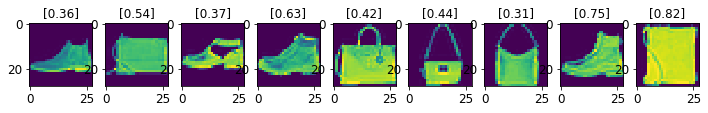

In [227]:
plt.figure(figsize=(12,6))
for i in range(9):    
    plt.subplot(191+i)
    plt.imshow(X_test_B[i]);
    plt.title(np.round(y_prob_B[i],2))

It looks like we need to train a bit more than just the last layer. Let us make them all layers trainable.

In [228]:
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = True

model_B_on_A.compile(loss="binary_crossentropy",
                     optimizer=keras.optimizers.SGD(lr=1e-3),
                     metrics=["accuracy"])
history = model_B_on_A.fit(X_train_B, y_train_B, epochs=16,
                           validation_data=(X_valid_B, y_valid_B))
model_B_on_A.evaluate(X_test_B, y_test_B)

Train on 200 samples, validate on 996 samples
Epoch 1/16
200/200 [==============================] - 1s 3ms/sample - loss: 0.6120 - accuracy: 0.6800 - val_loss: 0.5161 - val_accuracy: 0.7721
Epoch 2/16
200/200 [==============================] - 0s 391us/sample - loss: 0.4560 - accuracy: 0.8700 - val_loss: 0.4061 - val_accuracy: 0.9096
Epoch 3/16
200/200 [==============================] - 0s 354us/sample - loss: 0.3562 - accuracy: 0.9650 - val_loss: 0.3332 - val_accuracy: 0.9588
Epoch 4/16
200/200 [==============================] - 0s 362us/sample - loss: 0.2938 - accuracy: 0.9850 - val_loss: 0.2843 - val_accuracy: 0.9749
Epoch 5/16
200/200 [==============================] - 0s 352us/sample - loss: 0.2503 - accuracy: 0.9850 - val_loss: 0.2466 - val_accuracy: 0.9799
Epoch 6/16
200/200 [==============================] - 0s 365us/sample - loss: 0.2181 - accuracy: 0.9850 - val_loss: 0.2228 - val_accuracy: 0.9799
Epoch 7/16
200/200 [==============================] - 0s 365us/sample - loss: 0.

[0.10812464243173599, 0.987]

It did a good job now, but did the original training help at all? 

In [229]:
y_prob_B = model_B_on_A.predict(X_test_B)

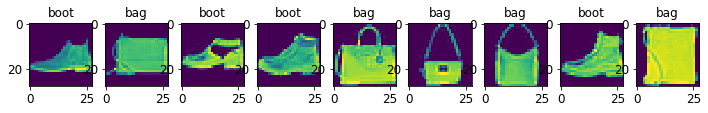

In [230]:
plt.figure(figsize=(12,6))
for i in range(9):    
    plt.subplot(191+i)
    plt.imshow(X_test_B[i]);plt.title(class_nameB[np.int8(y_test_B[i])])

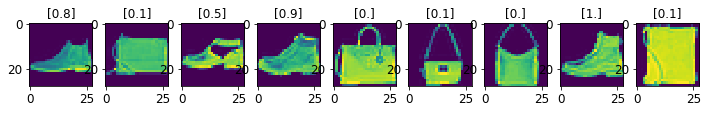

In [231]:
plt.figure(figsize=(12,6))
for i in range(9):    
    plt.subplot(191+i)
    plt.imshow(X_test_B[i]);
    #plt.title(class_nameB[np.int8(y_pred_B[i])])
    plt.title(np.round(y_prob_B[i],1))

In [232]:
y_pred_B = model_B_on_A.predict_classes(X_test_B)
y_pred_B = y_pred_B.flatten()
print(y_pred_B)

[1 0 1 ... 1 1 0]


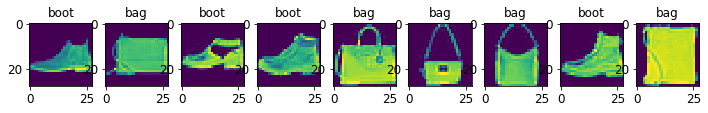

In [233]:
plt.figure(figsize=(12,6))
for i in range(9):    
    plt.subplot(191+i)
    plt.imshow(X_test_B[i]);
    plt.title(class_nameB[y_pred_B[i]])
    

## Exercise 5
Try the classification of the fashion mnist data set using the following optimizers.

In [8]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
pixel_means = X_train.mean(axis=0, keepdims=True)
pixel_stds = X_train.std(axis=0, keepdims=True)
X_train_scaled = (X_train - pixel_means) / pixel_stds
X_valid_scaled = (X_valid - pixel_means) / pixel_stds
X_test_scaled = (X_test - pixel_means) / pixel_stds

In [3]:
optimizer1 = keras.optimizers.SGD(lr=0.001, momentum=0.9)

In [4]:
optimizer2 = keras.optimizers.SGD(lr=0.001, momentum=0.9, nesterov=True)

In [5]:
optimizer3 = keras.optimizers.RMSprop(lr=0.001, rho=0.9)

In [6]:
optimizer4 = keras.optimizers.Adam(lr=0.001, beta_1=0.9, beta_2=0.999)

In [9]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer1, metrics=["accuracy"])

In [10]:
n_epochs = 10
history1 = model.fit(X_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(X_valid_scaled, y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 74us/sample - loss: 0.4875 - accuracy: 0.8296 - val_loss: 0.4084 - val_accuracy: 0.8598
Epoch 2/10
55000/55000 [==============================] - 3s 60us/sample - loss: 0.3793 - accuracy: 0.8651 - val_loss: 0.3897 - val_accuracy: 0.8618
Epoch 3/10
55000/55000 [==============================] - 3s 60us/sample - loss: 0.3446 - accuracy: 0.8781 - val_loss: 0.3682 - val_accuracy: 0.8694
Epoch 4/10
55000/55000 [==============================] - 3s 59us/sample - loss: 0.3214 - accuracy: 0.8849 - val_loss: 0.3528 - val_accuracy: 0.8734
Epoch 5/10
55000/55000 [==============================] - 3s 60us/sample - loss: 0.3024 - accuracy: 0.8898 - val_loss: 0.3646 - val_accuracy: 0.8690
Epoch 6/10
55000/55000 [==============================] - 3s 60us/sample - loss: 0.2876 - accuracy: 0.8957 - val_loss: 0.3337 - val_accuracy: 0.8810
Epoch 7/10
55000/55000 [==============================] -

In [11]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer4, metrics=["accuracy"])

In [12]:
history4 = model.fit(X_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(X_valid_scaled, y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 72us/sample - loss: 0.4898 - accuracy: 0.8311 - val_loss: 0.3829 - val_accuracy: 0.8638
Epoch 2/10
55000/55000 [==============================] - 3s 61us/sample - loss: 0.3513 - accuracy: 0.8724 - val_loss: 0.3573 - val_accuracy: 0.8752
Epoch 3/10
55000/55000 [==============================] - 3s 60us/sample - loss: 0.3097 - accuracy: 0.8859 - val_loss: 0.3289 - val_accuracy: 0.8840
Epoch 4/10
55000/55000 [==============================] - 3s 60us/sample - loss: 0.2853 - accuracy: 0.8942 - val_loss: 0.3503 - val_accuracy: 0.8802
Epoch 5/10
55000/55000 [==============================] - 3s 60us/sample - loss: 0.2648 - accuracy: 0.9010 - val_loss: 0.3547 - val_accuracy: 0.8782
Epoch 6/10
55000/55000 [==============================] - 3s 59us/sample - loss: 0.2442 - accuracy: 0.9084 - val_loss: 0.3613 - val_accuracy: 0.8824
Epoch 7/10
55000/55000 [==============================] -

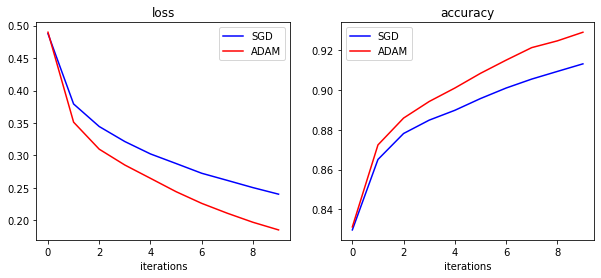

In [13]:
def plot_history(history, history2, case1, case2):
    niter=history.params['epochs']
    niter2=history.params['epochs']
    iter=np.arange(niter)
    iter2=np.arange(niter2)
    plt.figure(figsize=(10,4))
    plt.subplot(121);
    plt.plot(iter,history.history["loss"],'b-',label=case1);plt.plot(iter2,history2.history['loss'],'r-',label=case2)
    plt.xlabel('iterations')
    plt.title('loss')
    plt.legend()
    plt.subplot(122);
    plt.plot(iter,history.history["accuracy"],'b-',label=case1);plt.plot(iter2,history2.history['accuracy'],'r-',label=case2)
    plt.xlabel('iterations')
    plt.title('accuracy');
    plt.legend()
plot_history(history1,history4,'SGD','ADAM')

## Exercise 7: Learning Rate
Use the exponential rate decay defined below and compare with the previous result.

In [22]:
def exponential_decay(lr0, s):
    def exponential_decay_fn(epoch):
        return lr0 * 0.1**(epoch / s)
    return exponential_decay_fn

exponential_decay_fn = exponential_decay(lr0=0.001, s=20)

In [23]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer4, metrics=["accuracy"])

In [24]:
lr_scheduler = keras.callbacks.LearningRateScheduler(exponential_decay_fn)
history4b = model.fit(X_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(X_valid_scaled, y_valid),
                    callbacks=[lr_scheduler])

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 69us/sample - loss: 0.5150 - accuracy: 0.8356 - val_loss: 0.3574 - val_accuracy: 0.8654
Epoch 2/10
55000/55000 [==============================] - 3s 60us/sample - loss: 0.3282 - accuracy: 0.8789 - val_loss: 0.3632 - val_accuracy: 0.8724
Epoch 3/10
55000/55000 [==============================] - 3s 60us/sample - loss: 0.2874 - accuracy: 0.8924 - val_loss: 0.3398 - val_accuracy: 0.8814
Epoch 4/10
55000/55000 [==============================] - 3s 60us/sample - loss: 0.2529 - accuracy: 0.9050 - val_loss: 0.3204 - val_accuracy: 0.8890
Epoch 5/10
55000/55000 [==============================] - 3s 60us/sample - loss: 0.2248 - accuracy: 0.9152 - val_loss: 0.3159 - val_accuracy: 0.8840
Epoch 6/10
55000/55000 [==============================] - 3s 60us/sample - loss: 0.1991 - accuracy: 0.9252 - val_loss: 0.3138 - val_accuracy: 0.8908
Epoch 7/10
55000/55000 [==============================] -

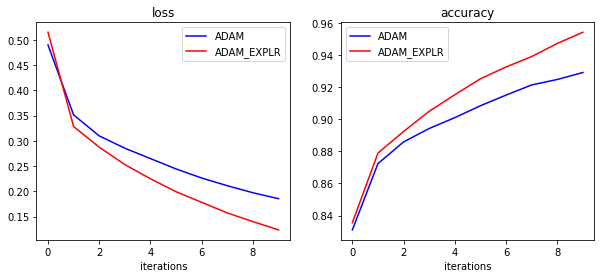

In [25]:
plot_history(history4,history4b,'ADAM','ADAM_EXPLR')

## Exercise 8: Regularization
Modify the previous network using l2 and l1 regularizations and compare with the previous result. Also compare with Dropout.

In [29]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal",kernel_regularizer=keras.regularizers.l2(0.001)),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal",kernel_regularizer=keras.regularizers.l2(0.001)),
    keras.layers.Dense(10, activation="softmax",kernel_regularizer=keras.regularizers.l2(0.001))
])
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer4, metrics=["accuracy"])

In [30]:
history4c = model.fit(X_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(X_valid_scaled, y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 73us/sample - loss: 0.7701 - accuracy: 0.8416 - val_loss: 0.5990 - val_accuracy: 0.8698
Epoch 2/10
55000/55000 [==============================] - 3s 62us/sample - loss: 0.5418 - accuracy: 0.8730 - val_loss: 0.5150 - val_accuracy: 0.8712
Epoch 3/10
55000/55000 [==============================] - 3s 63us/sample - loss: 0.4738 - accuracy: 0.8804 - val_loss: 0.4737 - val_accuracy: 0.8756
Epoch 4/10
55000/55000 [==============================] - 3s 63us/sample - loss: 0.4437 - accuracy: 0.8827 - val_loss: 0.4508 - val_accuracy: 0.8760
Epoch 5/10
55000/55000 [==============================] - 3s 63us/sample - loss: 0.4244 - accuracy: 0.8861 - val_loss: 0.4555 - val_accuracy: 0.8766
Epoch 6/10
55000/55000 [==============================] - 3s 63us/sample - loss: 0.4124 - accuracy: 0.8880 - val_loss: 0.4457 - val_accuracy: 0.8748
Epoch 7/10
55000/55000 [==============================] -

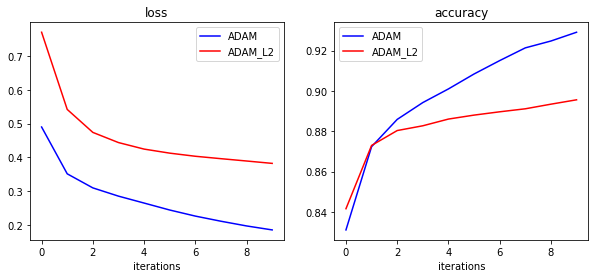

In [31]:
plot_history(history4,history4c,'ADAM','ADAM_L2')

In [39]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal",kernel_regularizer=keras.regularizers.l1(0.0001)),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal",kernel_regularizer=keras.regularizers.l1(0.0001)),
    keras.layers.Dense(10, activation="softmax",kernel_regularizer=keras.regularizers.l1(0.0001))
])
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer4, metrics=["accuracy"])

In [40]:
history4d = model.fit(X_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(X_valid_scaled, y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 73us/sample - loss: 1.0994 - accuracy: 0.8402 - val_loss: 0.8524 - val_accuracy: 0.8672
Epoch 2/10
55000/55000 [==============================] - 4s 64us/sample - loss: 0.7479 - accuracy: 0.8678 - val_loss: 0.7060 - val_accuracy: 0.8658
Epoch 3/10
55000/55000 [==============================] - 3s 63us/sample - loss: 0.6330 - accuracy: 0.8724 - val_loss: 0.6024 - val_accuracy: 0.8746
Epoch 4/10
55000/55000 [==============================] - 3s 63us/sample - loss: 0.5717 - accuracy: 0.8750 - val_loss: 0.5769 - val_accuracy: 0.8688
Epoch 5/10
55000/55000 [==============================] - 3s 63us/sample - loss: 0.5259 - accuracy: 0.8793 - val_loss: 0.5251 - val_accuracy: 0.8748
Epoch 6/10
55000/55000 [==============================] - 3s 62us/sample - loss: 0.4910 - accuracy: 0.8839 - val_loss: 0.5201 - val_accuracy: 0.8714
Epoch 7/10
55000/55000 [==============================] -

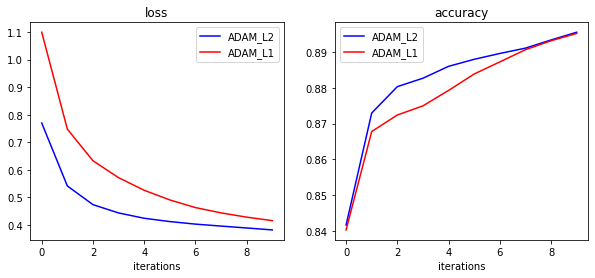

In [41]:
plot_history(history4c,history4d,'ADAM_L2','ADAM_L1')

### comparing with Dropout

In [44]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dropout(rate=0.2),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dropout(rate=0.2),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dropout(rate=0.2),
    keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer4, metrics=["accuracy"])

In [45]:
history5 = model.fit(X_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(X_valid_scaled, y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 76us/sample - loss: 0.6047 - accuracy: 0.8042 - val_loss: 0.3825 - val_accuracy: 0.8630
Epoch 2/10
55000/55000 [==============================] - 4s 65us/sample - loss: 0.4369 - accuracy: 0.8431 - val_loss: 0.3523 - val_accuracy: 0.8722
Epoch 3/10
55000/55000 [==============================] - 4s 65us/sample - loss: 0.3935 - accuracy: 0.8574 - val_loss: 0.3345 - val_accuracy: 0.8782
Epoch 4/10
55000/55000 [==============================] - 4s 66us/sample - loss: 0.3744 - accuracy: 0.8623 - val_loss: 0.3289 - val_accuracy: 0.8820
Epoch 5/10
55000/55000 [==============================] - 4s 65us/sample - loss: 0.3565 - accuracy: 0.8683 - val_loss: 0.3120 - val_accuracy: 0.8838
Epoch 6/10
55000/55000 [==============================] - 4s 66us/sample - loss: 0.3387 - accuracy: 0.8719 - val_loss: 0.3046 - val_accuracy: 0.8878
Epoch 7/10
55000/55000 [==============================] -

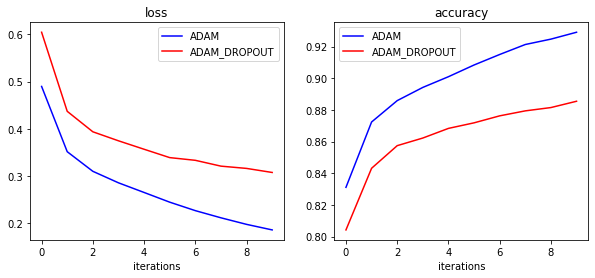

In [46]:
plot_history(history4,history5,'ADAM','ADAM_DROPOUT')